# Non-Autonomous Terms and VF-b Test
This notebook uses the best candidates from SINDy_FHN.ipynb for fitting data.  These include the following options:
* Model - VF-b (most realistic FHN model)
* Optimizer - SSR
* feature_library - degree 3 polynomials

In [24]:
import math
import numpy as np
from scipy.integrate import odeint
from itertools import combinations_with_replacement
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook"
import pandas as pd
import importlib
import SINDy
importlib.reload(SINDy)

import pysindy as ps

In [25]:
# The old, non-truncated autonomous term (can be a problem for large exponents).
# Params:
#   t (1d array): Time input vector
def smooth_non_aut_old(t):
    return 1. / (1. + np.exp((25*np.sin(0.02*t))**2))

# A differentiable non-autonomous term truncated from the Taylor series of the above term.
# Params:
#   t (1d array): Time input vector
def smooth_non_aut(t):
    return 1. / (2. + (200.*np.sin(0.02*t))**4)

# Logical step function non-autonomous term.
# Params:
#   t (1d array): Time input vector
#   period (float): The period of the stimulus
#   dur (float): The time duration of the stimulus
#   mag (float): The magnitude of the stimulus
def logical_non_aut(t):
    period, dur, mag = 155.0, 5.0, 0.1
    stimulus = mag * (np.mod(t, period) <= dur)
    
    return stimulus

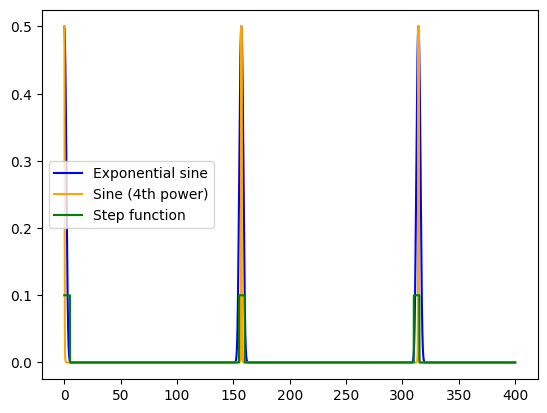

In [26]:
# Compare the forcing functions. Note that we can't actually use the exponential since it will encounter overflow for the peak tightness
# that we need; instead, take part of the Taylor series, then throw out the terms we don't need while still maintaing a representative shape.
t = np.arange(0,400,0.01)
plt.plot(t, smooth_non_aut_old(t), color = 'blue', label='Exponential sine')
plt.plot(t, smooth_non_aut(t), color='orange', label='Sine (4th power)')
plt.plot(t, logical_non_aut(t), color='green', label='Step function')
plt.legend()

# 1.) VF-FHN
Now, let's try fitting the above with some non-autonomous terms included.

In [27]:
'''
Generate the data using the VF-b modified FHN equations:
Params:
    state (2d array):        Contains the state variables u and v
    t (1d array):            Time input
    non_aut_term (1d array): A non-autonomous term to be added to the u_dot equation
    alpha = 0.2, beta = 1.1, gamma = 0.31, delta = 1.0, eps = 0.005, theta = -0.05, mu = 1.0 (Old auto-oscillatory parameters used to get these equations)
'''
def fhn_vf_b(state, t, non_aut_term, alpha = 0.2, beta = 1.1, gamma = 0.31, delta = 0.0, eps = 0.005, theta = -0.05, mu = 1.0):
    u, v = state
    u_dot = mu*u*(1 - u)*(u - alpha) - u*v # Note - version w/out unrealistic hyperpolarization has -u*v instead of -v. However, only get full domain with -v (why?)
    v_dot = eps*((beta - u)*(u - gamma) - delta*v - theta)

    # Add time-dependent voltage perturbation
    u_dot +=  non_aut_term(t)
    return u_dot, v_dot

# Time step and initial values; seems like 0-600 is minimum timeframe needed to identify dynamics
dt = 0.01
t_vf_b = np.arange(0,2000,dt)   # Note: t around 3000 and above causes tab to crash
x_0_vf_b = np.array([0,0])
states_vf_b = odeint(fhn_vf_b, x_0_vf_b, t_vf_b, args=(logical_non_aut,), hmax=0.1) # Test code --> lambda t: 0         Actual code --> logical_non_aut

In [28]:
# Run SINDy on VF-FHN w/ time-varying terms.
# Note: There are some extraneous terms hiding around precision = 6-10 that show up, but they shouldn't affect the solution much.
# TODO How to remove these terms?
opt_vf_b = ps.SSR(alpha=0.00001)
model_vf_b = ps.SINDy(feature_names=["u", "v"], feature_library=ps.PolynomialLibrary(degree=3), optimizer=opt_vf_b)
model_vf_b.fit(states_vf_b, t=t_vf_b)
model_vf_b.print(precision=5)

(u)' = 0.00232 1 + 0.64685 u + 0.07053 v + -0.74131 u^2 + -4.93710 u v + -1.02308 v^2 + 0.09142 u^3 + 4.13788 u^2 v + 5.84911 u v^2 + 2.04352 v^3
(v)' = -0.00145 1 + 0.00705 u + -0.00500 u^2


Actual equations for comparison (without auto-oscillatory term $\delta$):

\begin{align}
    \dot{u} &= - 0.2 u + 1.2 u^2 - u v - 1 u^3 \\
    \dot{v} &= -0.001455 + 0.00705u - 0.005u^2 \\
\end{align}

And with $\delta=1.0$:

\begin{align}
    \dot{u} &= - 0.2 u + 1.2 u^2 - u v - 1 u^3 \\
    \dot{v} &= -0.001455 + 0.00705u - 0.005u^2 - 0.005v \\
\end{align}

Text(0.5, 1.0, 'Values of u vs. v')

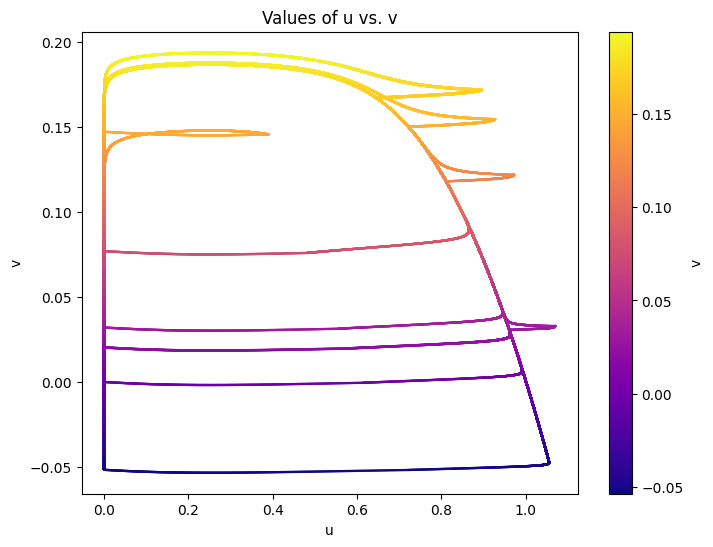

In [29]:
# Plot results - u vs. v
df_states_vf_b = pd.DataFrame(states_vf_b, columns=['u','v'])

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_states_vf_b['u'], 
    df_states_vf_b['v'], 
    c=df_states_vf_b['v'],  # Color shade controlled by v column
    s=0.5,  # Marker size
    cmap='plasma'
)

# Add colorbar for the v values
plt.colorbar(scatter, label='v')
plt.xlabel('u')
plt.ylabel('v')
plt.title('Values of u vs. v')

[0.0, 0.0009990085969232853, 0.0019960447584301613, 0.0029911353592793066, 0.0039843110980379804, 0.004975588628582789, 0.005965000630746318, 0.006952578272981813, 0.007938352723742513, 0.008922349905105775]
[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09]


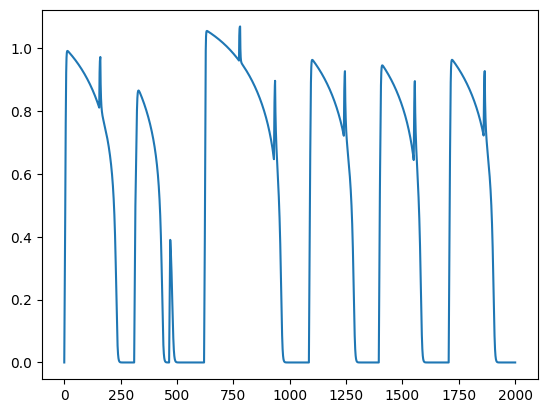

In [30]:
# Plot result - time domain - u vs. t
u_vf_b = df_states_vf_b['u'].tolist()
print(u_vf_b[0:10])
print(t_vf_b[0:10])

plt.plot(t_vf_b,u_vf_b)

# 2.) FHN
Now, fit standard FHN model with non-autonomous terms.

In [31]:
'''
Standard FitzHugh-Nagumo equations for comparison w/ the above method.
Params:
    state (2d array):        Contains the state variables u and v
    t (1d array):            Time input
    non_aut_term (1d array): A non-autonomous term to be added to the u_dot equation
    alpha = 0.2, beta = 1.1, gamma = 0.31, delta = 0.0, eps = 0.005 (delta = 1.0 for auto-oscillatory state)
'''
def fhn(state, t, non_aut_term, alpha = 0.1, beta = 0.5, gamma = 1, delta = 0.0, eps = 0.01):
    u, v = state
    u_dot = u*(1-u)*(u-alpha) - v   # Note - the cardiac version has -u*v instead of -v. For some reason, can only get the full domain with -v
    v_dot = eps*(beta*u - gamma*v - delta)

    # Add time-dependent voltage perturbation
    u_dot +=  non_aut_term(t)
    return u_dot, v_dot

# Standard FHN parameters
t_fhn = np.arange(0,2000,dt)   # Note: t around 3000 and above causes tab to crash
x_0_fhn = np.array([0,0])
states_fhn = odeint(fhn, x_0_fhn, t_fhn, args=(logical_non_aut,), hmax=0.1) # Test code --> lambda t: 0         Actual code --> logical_non_aut

In [32]:
# Run SINDy on FHN w/ time-varying terms.
# Note: There are some extraneous terms hiding around precision = 6-10 that show up, but they shouldn't affect the solution much.
# TODO How to remove these terms?
opt_fhn = ps.SSR(alpha=0.00001)
model_fhn = ps.SINDy(feature_names=["u", "v"], feature_library=ps.PolynomialLibrary(degree=3), optimizer=opt_fhn)
model_fhn.fit(states_fhn, t=t_fhn)
model_fhn.print(precision=5)

(u)' = 0.03122 1 + 0.44020 u + 0.40723 v + -0.15695 u^2 + -7.70239 u v + -15.78437 v^2 + -0.28263 u^3 + 5.43972 u^2 v + 24.78611 u v^2 + 42.11850 v^3
(v)' = 0.00500 u + -0.01000 v


Actual equations for comparison (without auto-oscillatory term $\delta$):

\begin{align}
    \dot{u} &= - 0.1 u + 1.1 u^2 - 1 uv - 1 u^3 \\
    \dot{v} &= 0.005 - 0.01v \\
\end{align}

And with $\delta=1.0$:

\begin{align}
    \dot{u} &= - 0.1 u + 1.1 u^2 - 1uv - 1 u^3 \\
    \dot{v} &= - 0.01 + 0.005 - 0.01v \\
\end{align}

Text(0.5, 1.0, 'Values of u vs. v')

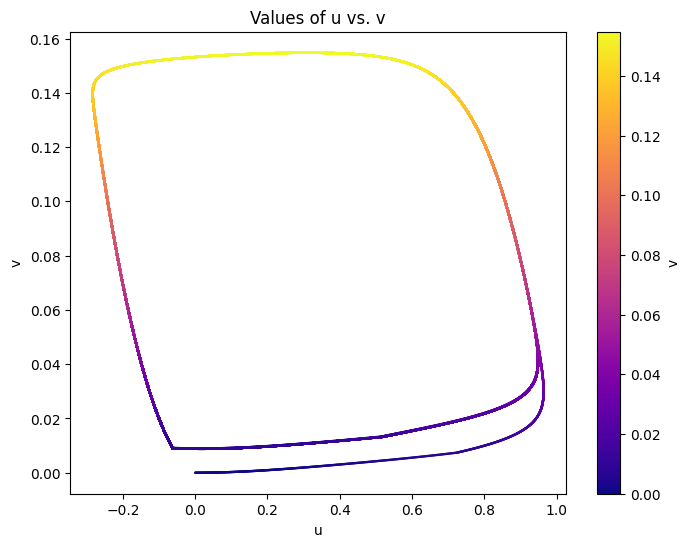

In [33]:
# Plot results - u vs. v
df_states_fhn = pd.DataFrame(states_fhn, columns=['u','v'])

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_states_fhn['u'], 
    df_states_fhn['v'], 
    c=df_states_fhn['v'],  # Color shade controlled by v column
    s=0.5,  # Marker size
    cmap='plasma'
)

# Add colorbar for the v values
plt.colorbar(scatter, label='v')
plt.xlabel('u')
plt.ylabel('v')
plt.title('Values of u vs. v')

[0.0, 0.0009995068462408396, 0.0019980356604502683, 0.0029956078983891733, 0.003992248139315162, 0.004987969647643113, 0.005982798278903055, 0.006976758643208527, 0.007969875350673061, 0.0089621726926662]
[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09]


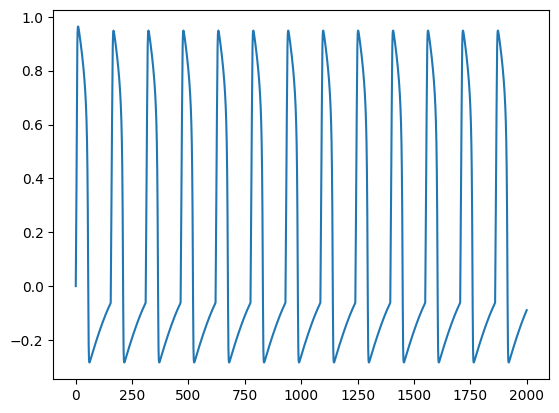

In [34]:
# Plot result - time domain - u vs. t
u_fhn = df_states_fhn['u'].tolist()
print(u_fhn[0:10])
print(t_fhn[0:10])

plt.plot(t_fhn,u_fhn)